# pipeline_versiones9: matrices Control vs TEA en ABIDE I

Esta version se enfoca en visualizar e interpretar matrices de conectividad cerebral promedio para sujetos Control y sujetos TEA. No es una version centrada en accuracy ni clasificacion.

Metodos incluidos:

- Correlacion
- Lasso
- LiNGAM

No se incluyen Granger ni PCMCI en esta version.


## Objetivo de tesis

Para cada metodo se cargan las matrices individuales por sujeto, se separan sujetos Control y TEA, y se generan:

- Heatmap de matriz promedio Control.
- Heatmap de matriz promedio TEA.
- Heatmap de diferencia `TEA - Control`.
- Matriz de diferencia en magnitud `abs(TEA) - abs(Control)`.
- Tabla de conexiones mas diferentes para contrastar con literatura sobre TEA.

Las metricas globales de magnitud y sparsity quedan como apoyo, no como resultado principal.


In [1]:
# CELDA 1 - Configuracion general v9

from pathlib import Path
import sys

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

NOTEBOOK_ROOT = Path.cwd()
if not (NOTEBOOK_ROOT / "pipeline_versiones9" / "analisis_control_tea.py").exists():
    if (NOTEBOOK_ROOT / "analisis_control_tea.py").exists():
        NOTEBOOK_ROOT = NOTEBOOK_ROOT.parent
    else:
        raise RuntimeError("Abre este notebook desde la raiz de Tesis Segunda Entrega o ajusta NOTEBOOK_ROOT.")

V9_MODULE_DIR = NOTEBOOK_ROOT / "pipeline_versiones9"
if str(V9_MODULE_DIR.resolve()) not in sys.path:
    sys.path.insert(0, str(V9_MODULE_DIR.resolve()))

from analisis_control_tea import (
    generate_interpretation_report,
    load_method_data,
    load_subject_manifest,
    run_group_connectivity_analysis,
)

SOURCE_RESULTS = NOTEBOOK_ROOT / "resultados" / "pipeline_schaefer_100_all_valid_100rois_tp146"
OUT_V9 = NOTEBOOK_ROOT / "resultados" / "pipeline_versiones9"

METHODS_ORDER = [
    "correlacion",
    "lasso",
    "lingam",
]

SPARSITY_THRESHOLDS = (1e-5, 1e-4, 1e-3)
TOP_N_CONNECTIONS_PER_METHOD = 100

print("Base funcional:", SOURCE_RESULTS)
print("Salida pipeline_versiones9:", OUT_V9)
print("Metodos:", METHODS_ORDER)


Base funcional: c:\Users\crist\OneDrive\Escritorio\Tesis Segunda Entrega\resultados\pipeline_schaefer_100_all_valid_100rois_tp146
Salida pipeline_versiones9: c:\Users\crist\OneDrive\Escritorio\Tesis Segunda Entrega\resultados\pipeline_versiones9
Metodos: ['correlacion', 'lasso', 'lingam']


## 1. Verificar sujetos y matrices individuales

Esta celda confirma que los sujetos, etiquetas y matrices existen en la corrida base. La correspondencia sujeto-matriz se mantiene usando el orden de `sujetos_incluidos.csv`.


In [2]:
# CELDA 2 - Verificacion de cohorte y matrices cacheadas

manifest = load_subject_manifest(SOURCE_RESULTS)
cohort_summary = pd.DataFrame(
    {
        "n_subjects": [len(manifest)],
        "Control": [int((manifest["group"] == "Control").sum())],
        "TEA": [int((manifest["group"] == "TEA").sum())],
        "n_rois": [int(manifest["n_rois"].iloc[0])],
        "min_timepoints": [int(manifest["n_timepoints"].min())],
        "max_timepoints": [int(manifest["n_timepoints"].max())],
    }
)
display(cohort_summary)

matrix_check_rows = []
for method in METHODS_ORDER:
    data = load_method_data(SOURCE_RESULTS, method, manifest)
    matrix_check_rows.append(
        {
            "method": method,
            "directed": data.directed,
            "n_matrices": data.matrices.shape[0],
            "matrix_shape": str(data.matrices.shape[1:]),
            "first_diag_abs_max": float(np.abs(np.diag(data.matrices[0])).max()),
            "first_symmetry_max_abs_diff": float(np.abs(data.matrices[0] - data.matrices[0].T).max()),
        }
    )

display(pd.DataFrame(matrix_check_rows))


,n_subjects,Control,TEA,n_rois,min_timepoints,max_timepoints
0,723,394,329,100,146,316


,method,directed,n_matrices,matrix_shape,first_diag_abs_max,first_symmetry_max_abs_diff
0,correlacion,False,723,"(100, 100)",1.0,0.0
1,lasso,False,723,"(100, 100)",1.0,0.0
2,lingam,True,723,"(100, 100)",0.0,1.0


## 2. Generar matrices promedio, diferencias y heatmaps

La diagonal se excluye de todos los calculos cuantitativos y se guarda en cero en las matrices promedio/diferencia para que no domine la escala visual.

LiNGAM se mantiene dirigido. No se fuerza simetria en su analisis principal.


In [3]:
# CELDA 3 - Ejecutar pipeline_versiones9

results_v9 = run_group_connectivity_analysis(
    source_dir=SOURCE_RESULTS,
    output_dir=OUT_V9,
    methods=METHODS_ORDER,
    thresholds=SPARSITY_THRESHOLDS,
    top_n_edges=TOP_N_CONNECTIONS_PER_METHOD,
)

print("pipeline_versiones9 completado")
print("Matrices:", OUT_V9 / "matrices")
print("Figuras:", OUT_V9 / "figures")
print("Tablas:", OUT_V9 / "tables")


pipeline_versiones9 completado
Matrices: c:\Users\crist\OneDrive\Escritorio\Tesis Segunda Entrega\resultados\pipeline_versiones9\matrices
Figuras: c:\Users\crist\OneDrive\Escritorio\Tesis Segunda Entrega\resultados\pipeline_versiones9\figures
Tablas: c:\Users\crist\OneDrive\Escritorio\Tesis Segunda Entrega\resultados\pipeline_versiones9\tables


## 3. Figuras principales: Control, TEA y TEA - Control

Estas son las figuras centrales para presentar la comparacion visual de conectividad cerebral entre grupos.


correlacion_control_tea_diff_panel.png


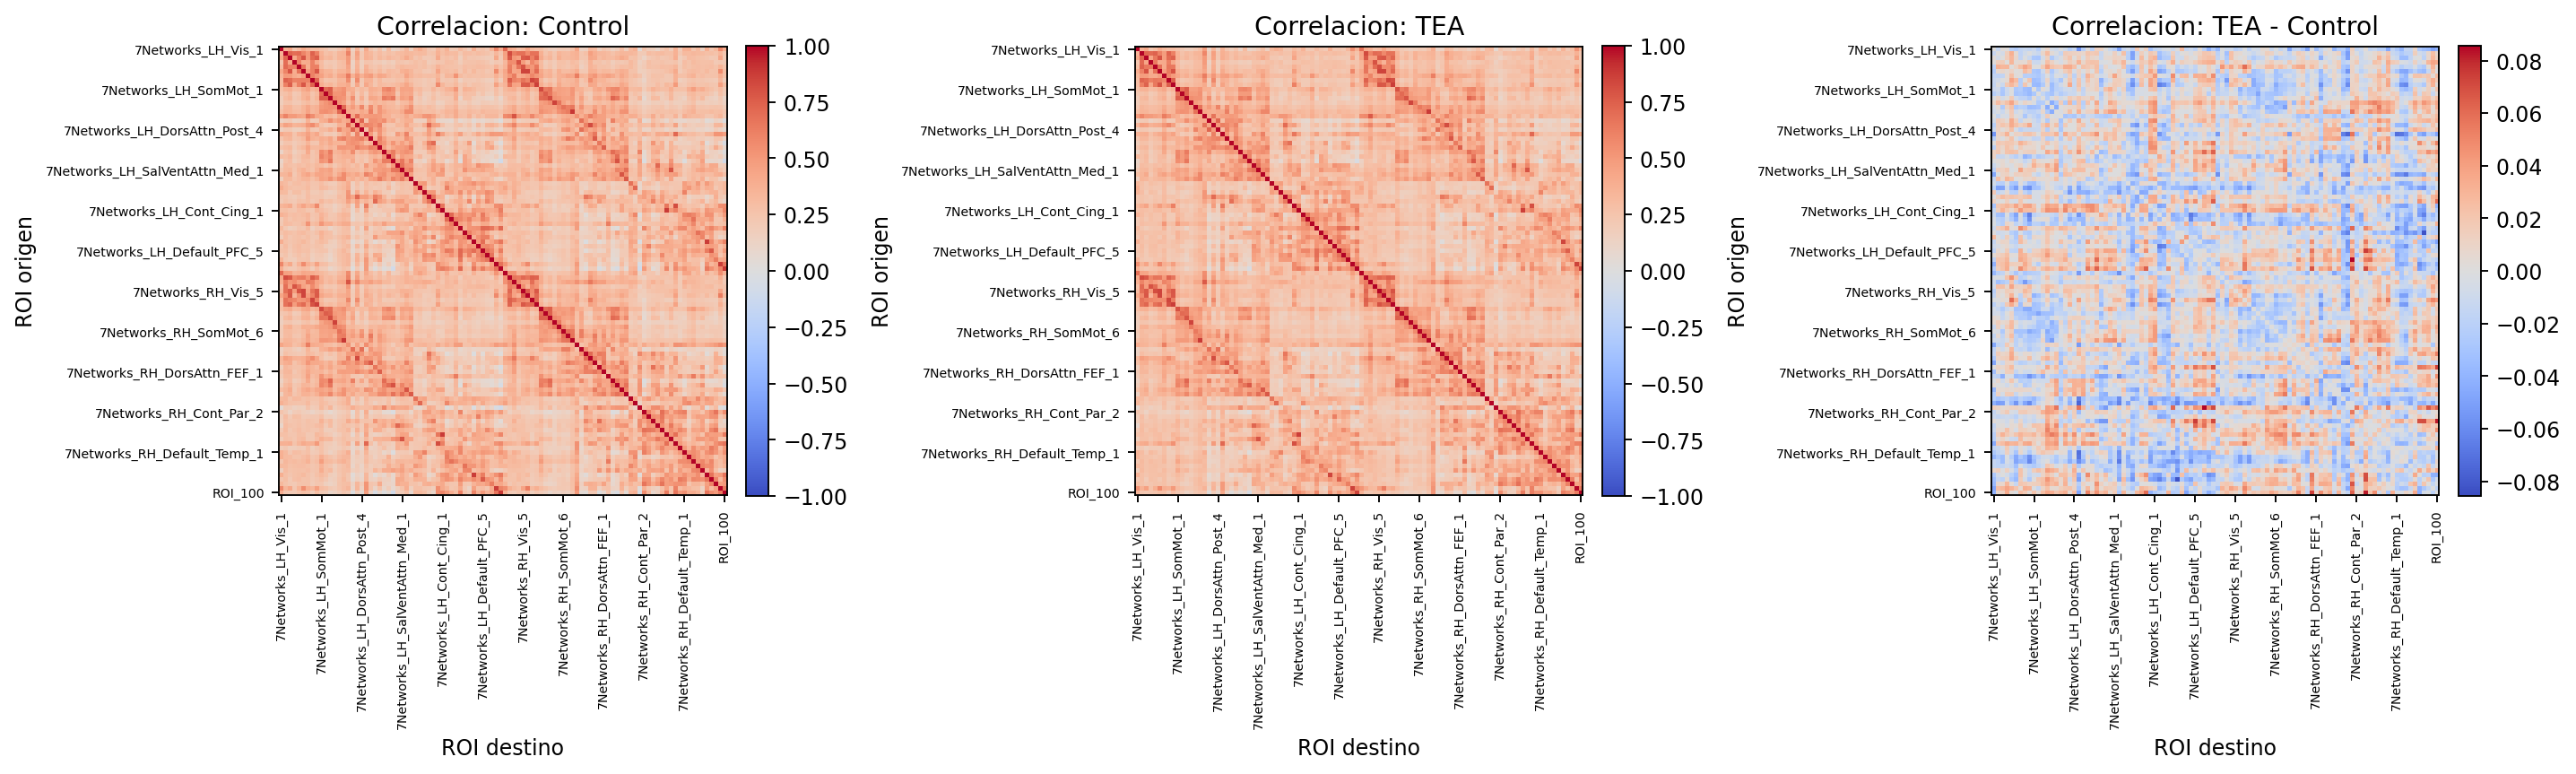

lasso_control_tea_diff_panel.png


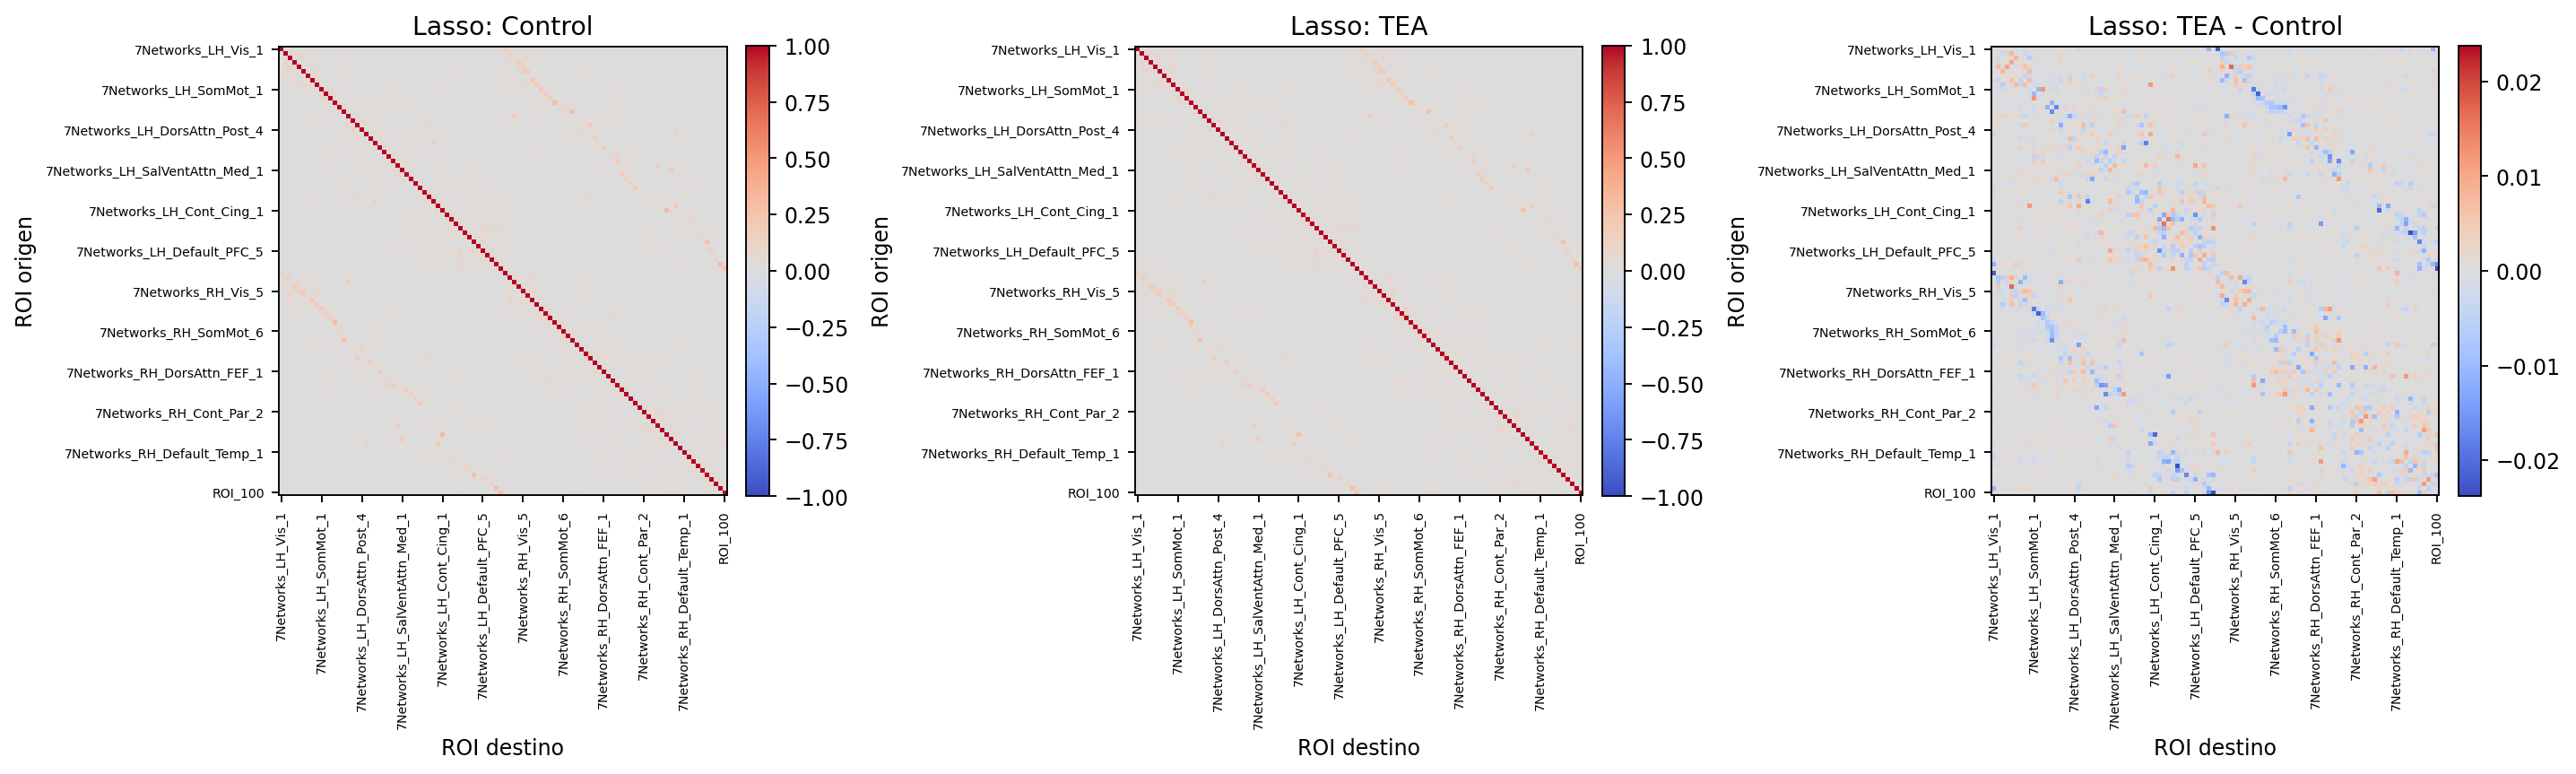

lingam_control_tea_diff_panel.png


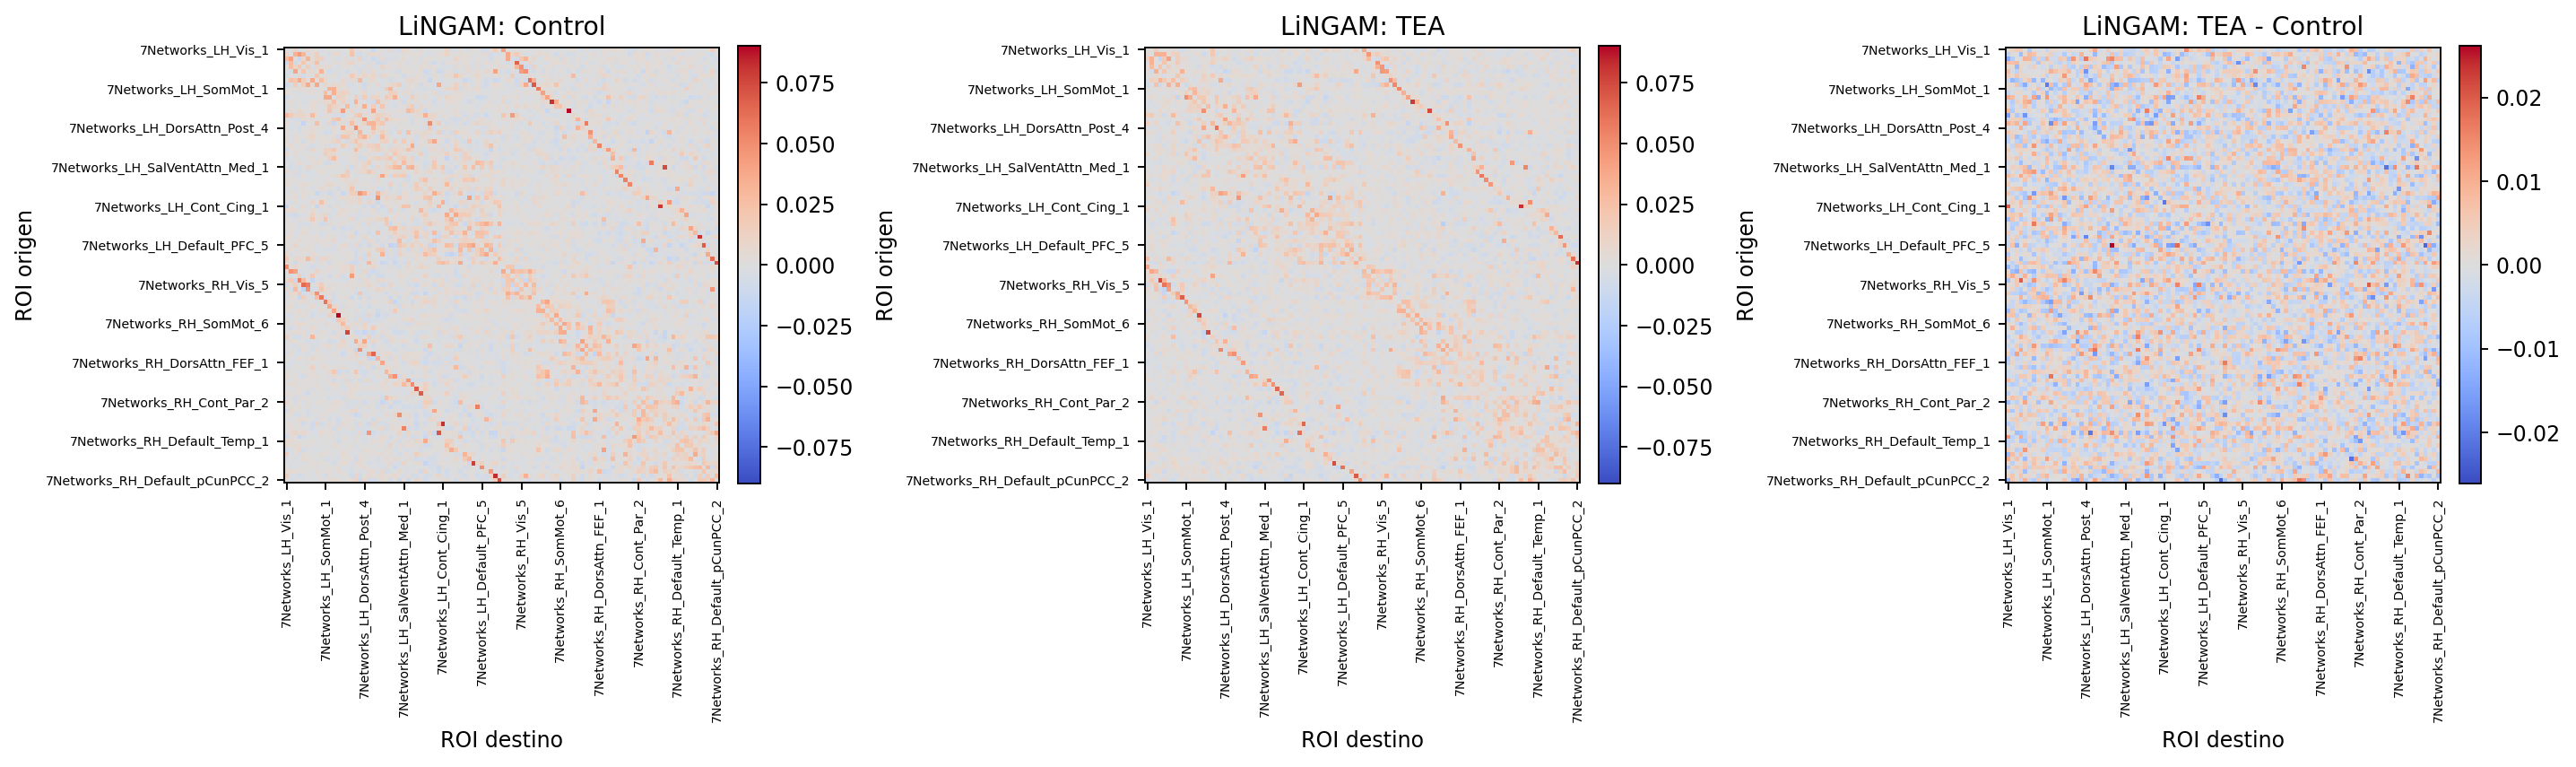

In [4]:
# CELDA 4 - Mostrar paneles principales Control | TEA | TEA-Control

for method in METHODS_ORDER:
    fig_path = OUT_V9 / "figures" / f"{method}_control_tea_diff_panel.png"
    print(fig_path.name)
    display(Image(filename=str(fig_path)))


## 4. Matriz de diferencia en magnitud

`abs_diff_matrix = abs(mean_matrix_TEA) - abs(mean_matrix_Control)` permite ver donde TEA tiene conexiones de mayor o menor magnitud absoluta, independiente del signo.


correlacion_abs_diff_tea_minus_control_heatmap.png


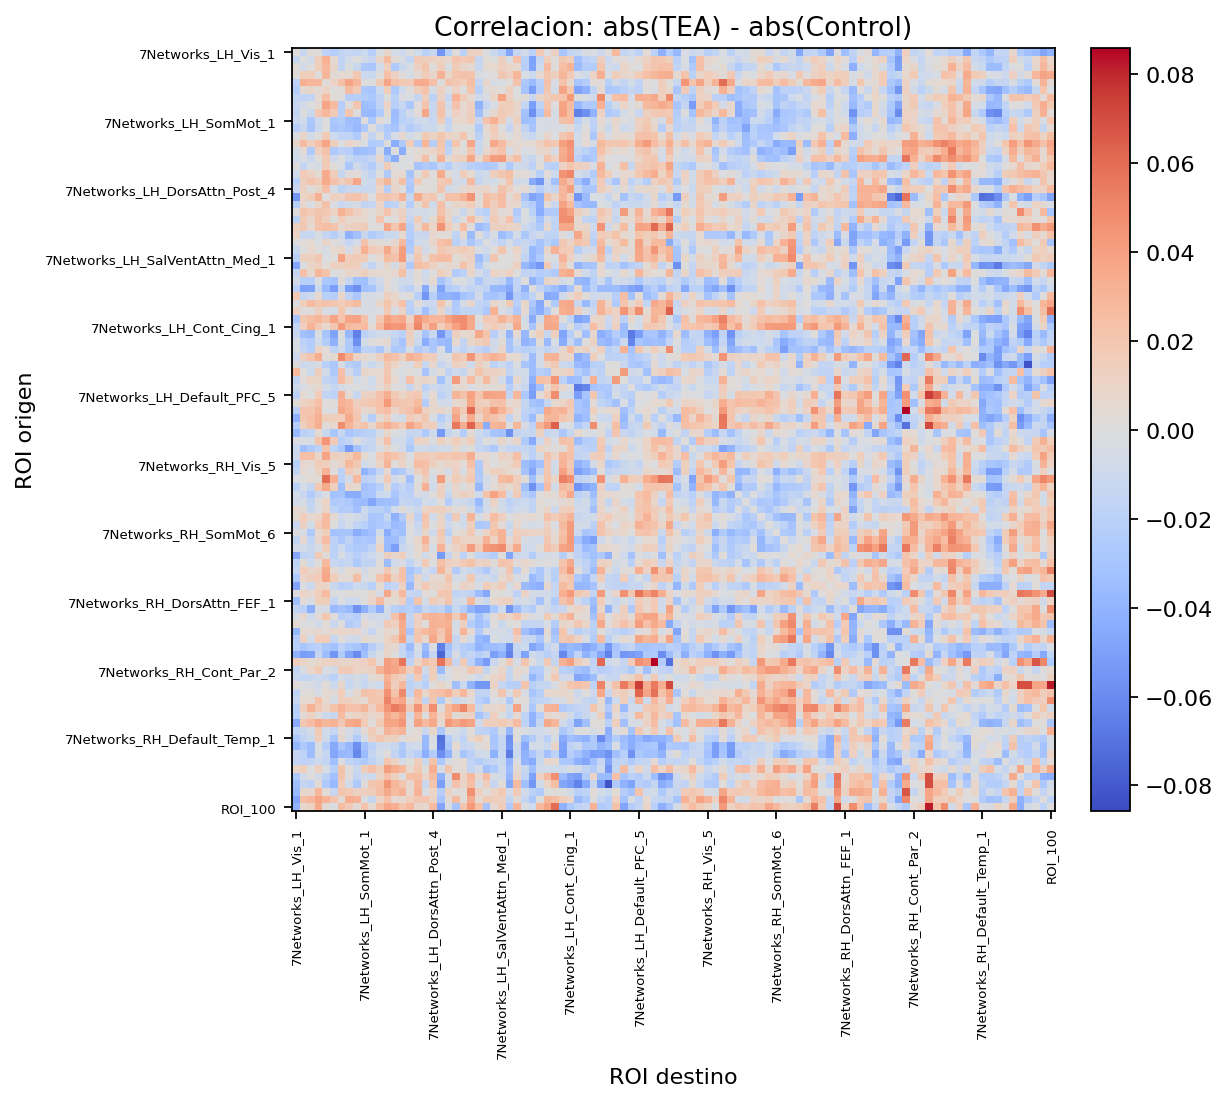

lasso_abs_diff_tea_minus_control_heatmap.png


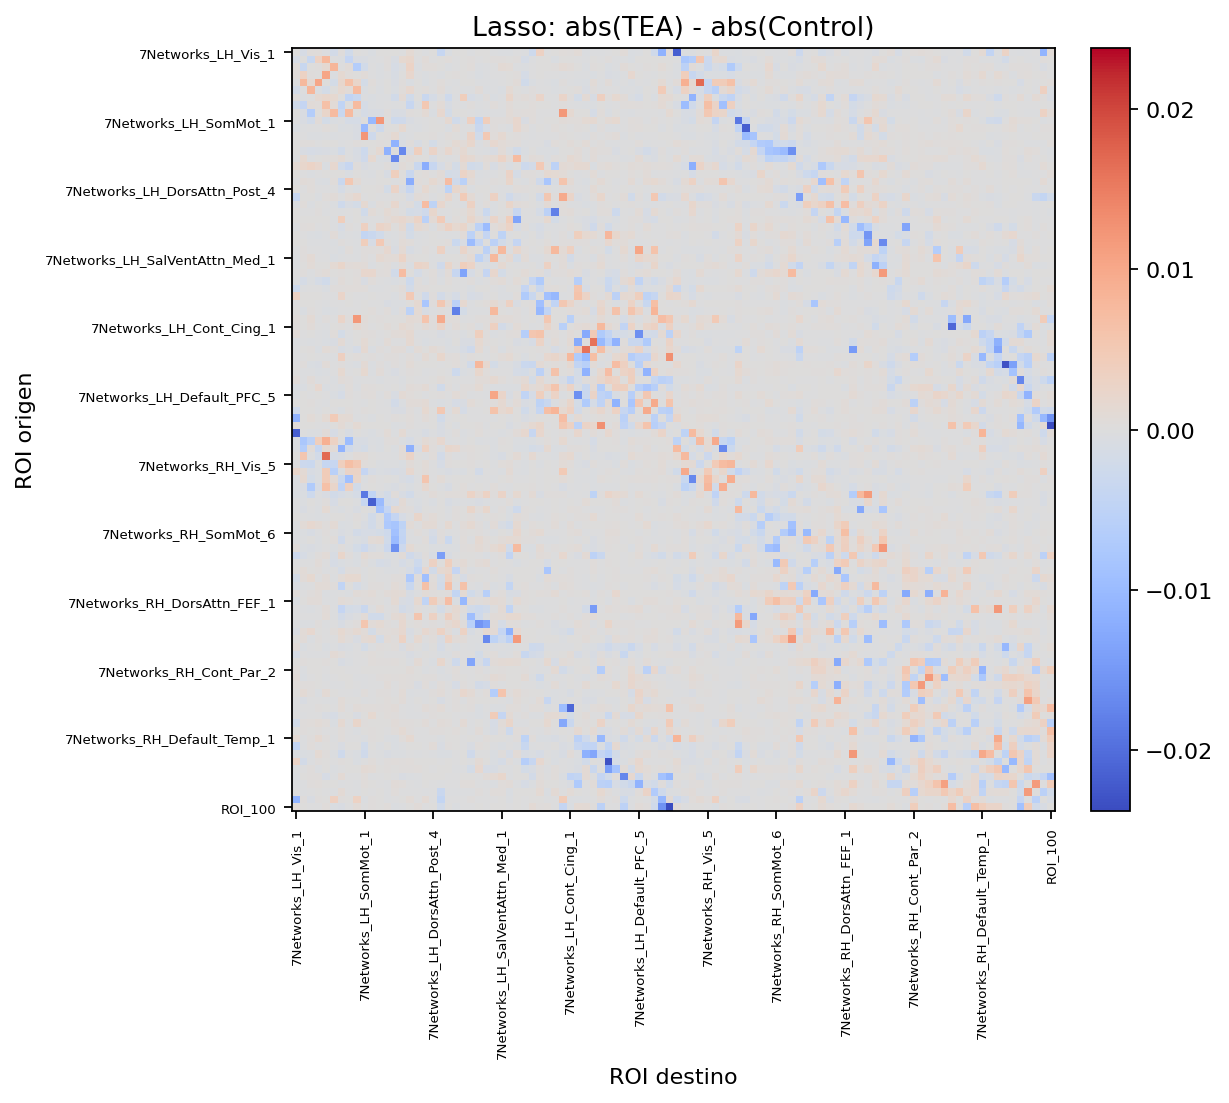

lingam_abs_diff_tea_minus_control_heatmap.png


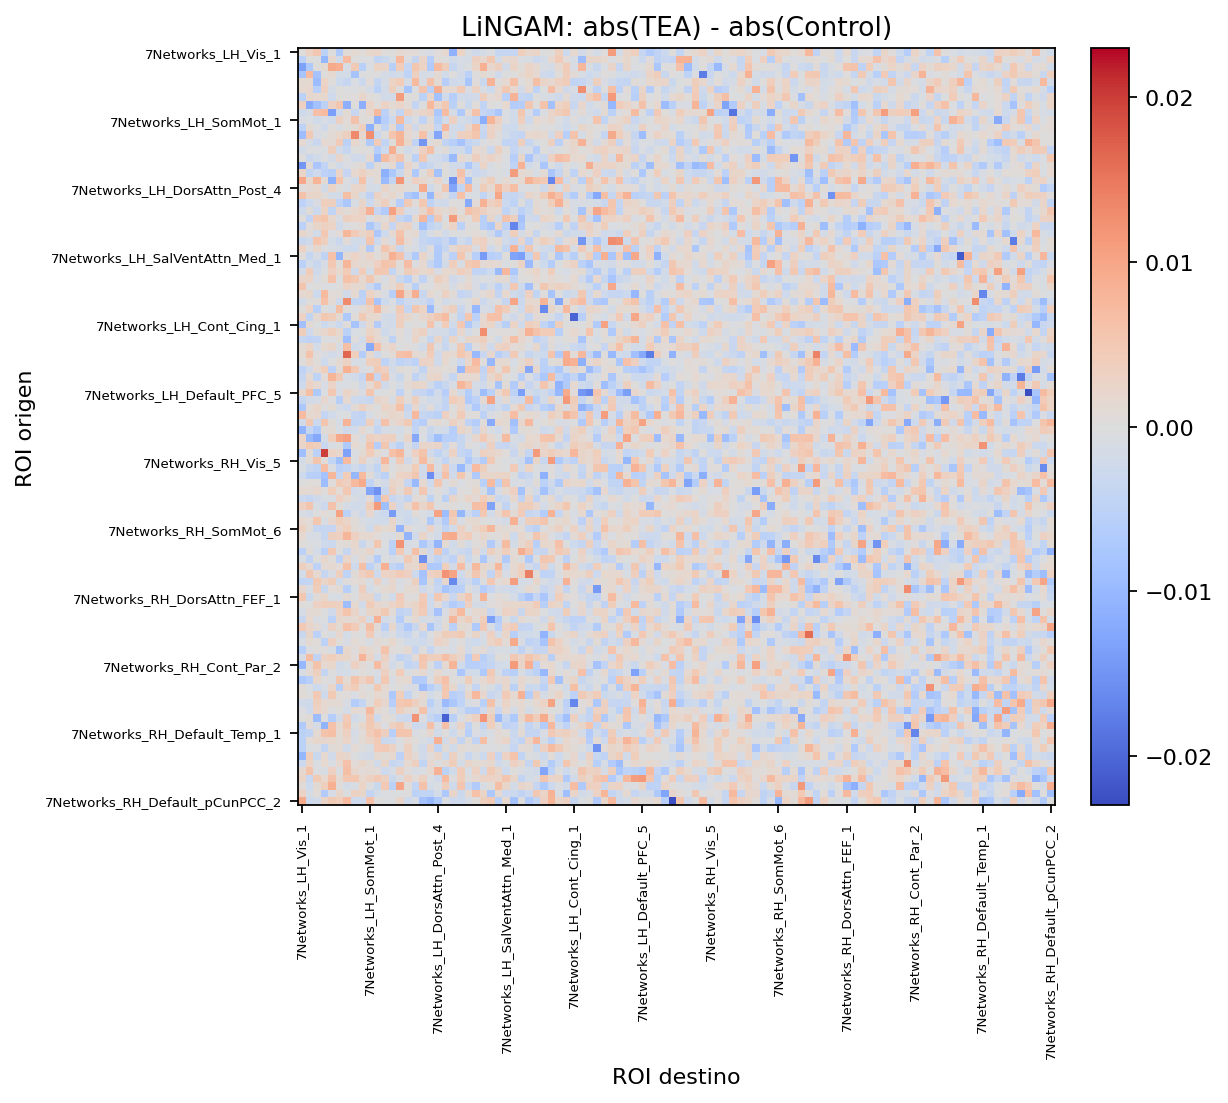

In [5]:
# CELDA 5 - Mostrar heatmaps de diferencia en magnitud absoluta

for method in METHODS_ORDER:
    fig_path = OUT_V9 / "figures" / f"{method}_abs_diff_tea_minus_control_heatmap.png"
    print(fig_path.name)
    display(Image(filename=str(fig_path)))


## 5. Conexiones mas diferentes para contrastar con literatura

La tabla `top_different_connections.csv` es la tabla principal para revisar si las conexiones mas distintas involucran redes o regiones reportadas en TEA, como Default Mode Network, precuneus/PCC, medial prefrontal cortex, temporoparietal junction, salience network, regiones fronto-temporales, talamo-corticales o cerebelo.


In [6]:
# CELDA 6 - Top conexiones diferentes TEA vs Control

top_connections_path = OUT_V9 / "tables" / "top_different_connections.csv"
top_connections = pd.read_csv(top_connections_path)

display(
    top_connections[
        [
            "rank_overall",
            "rank_within_method",
            "method",
            "roi_i",
            "roi_j",
            "control_value",
            "tea_value",
            "difference_tea_minus_control",
            "abs_difference",
            "direction",
            "sign_interpretation",
        ]
    ].head(40)
)


,rank_overall,rank_within_method,method,roi_i,roi_j,control_value,tea_value,difference_tea_minus_control,abs_difference,direction,sign_interpretation
0,1,1,correlacion,7Networks_LH_Default_PFC_7,7Networks_RH_Cont_Par_1,0.111556,0.197245,0.085689,0.085689,undirected,higher_in_TEA
1,2,2,correlacion,7Networks_LH_Default_PFC_1,7Networks_RH_Default_PFCdPFCm_2,0.480668,0.397894,-0.082774,0.082774,undirected,lower_in_TEA
2,3,3,correlacion,7Networks_RH_Cont_PFCl_2,ROI_100,0.078573,0.160625,0.082052,0.082052,undirected,higher_in_TEA
3,4,4,correlacion,7Networks_LH_DorsAttn_Post_5,7Networks_RH_Limbic_TempPole_1,0.293574,0.217965,-0.075609,0.075609,undirected,lower_in_TEA
4,5,5,correlacion,7Networks_LH_Default_PFC_5,7Networks_RH_Cont_PFCl_2,0.133913,0.208516,0.074603,0.074603,undirected,higher_in_TEA
5,6,6,correlacion,7Networks_RH_DorsAttn_PrCv_1,ROI_100,-0.001726,0.072488,0.074214,0.074214,undirected,higher_in_TEA
6,7,7,correlacion,7Networks_LH_Default_pCunPCC_2,7Networks_RH_Cont_PFCl_2,0.037038,0.108442,0.071404,0.071404,undirected,higher_in_TEA
7,8,8,correlacion,7Networks_LH_DorsAttn_Post_5,7Networks_RH_Default_Temp_1,0.348090,0.276976,-0.071115,0.071115,undirected,lower_in_TEA
8,9,9,correlacion,7Networks_LH_Default_pCunPCC_2,7Networks_RH_Cont_Par_1,-0.082629,-0.011734,0.070896,0.070896,undirected,higher_in_TEA
9,10,10,correlacion,7Networks_RH_Cont_PFCl_2,7Networks_RH_Default_PFCdPFCm_2,0.290716,0.360425,0.069709,0.069709,undirected,higher_in_TEA


## 6.1. Heatmaps de conexiones top

Estos heatmaps dejan en cero todas las conexiones excepto las mas diferentes entre TEA y Control. Sirven para ver rapidamente donde se concentran las diferencias principales.

correlacion_top_100_different_connections_heatmap.png


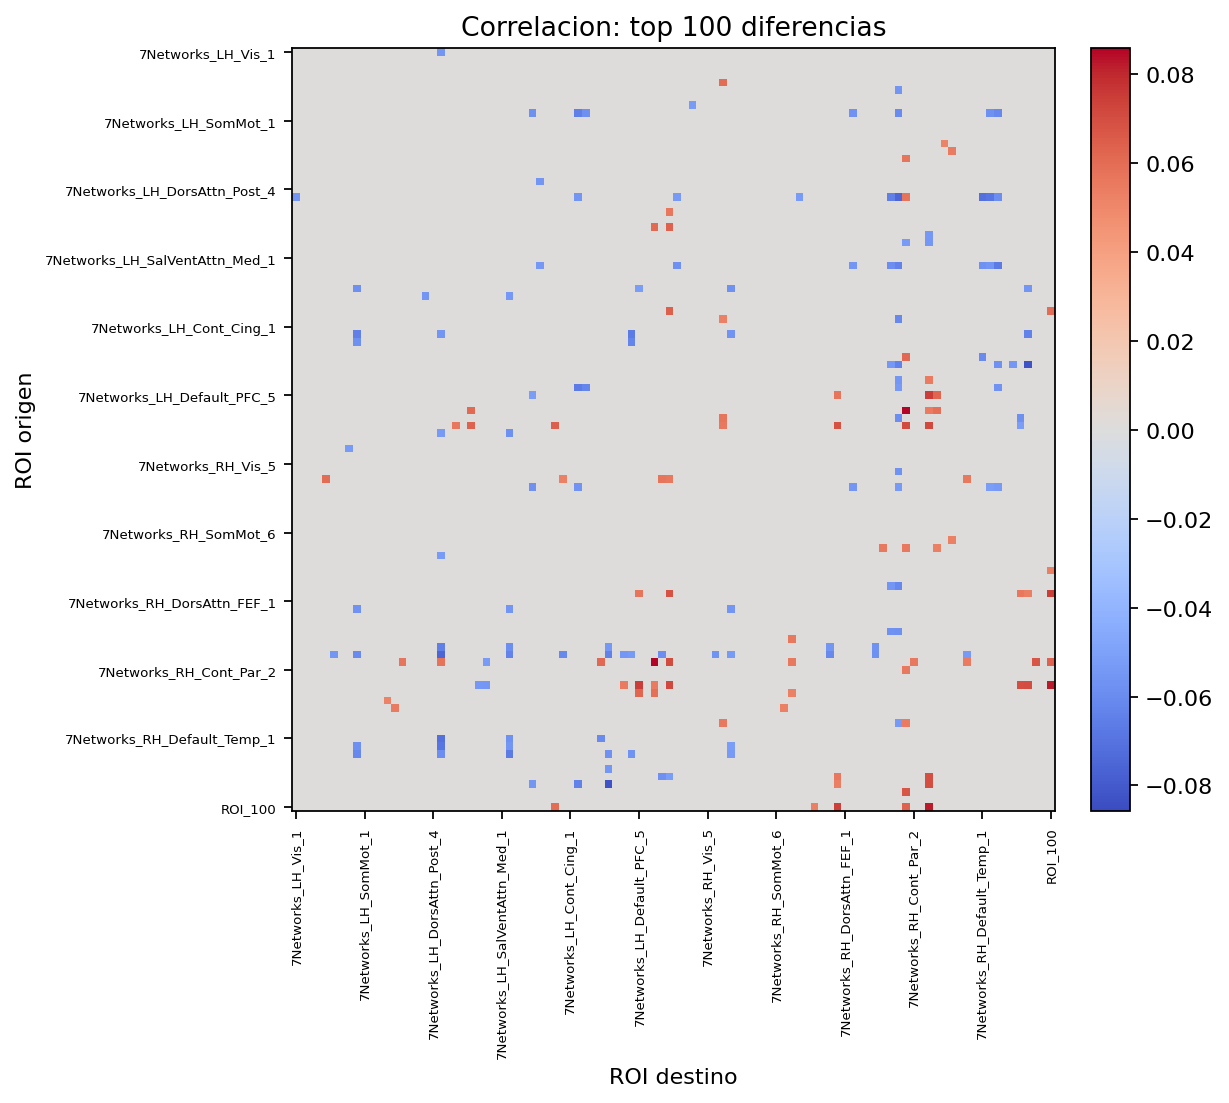

lasso_top_100_different_connections_heatmap.png


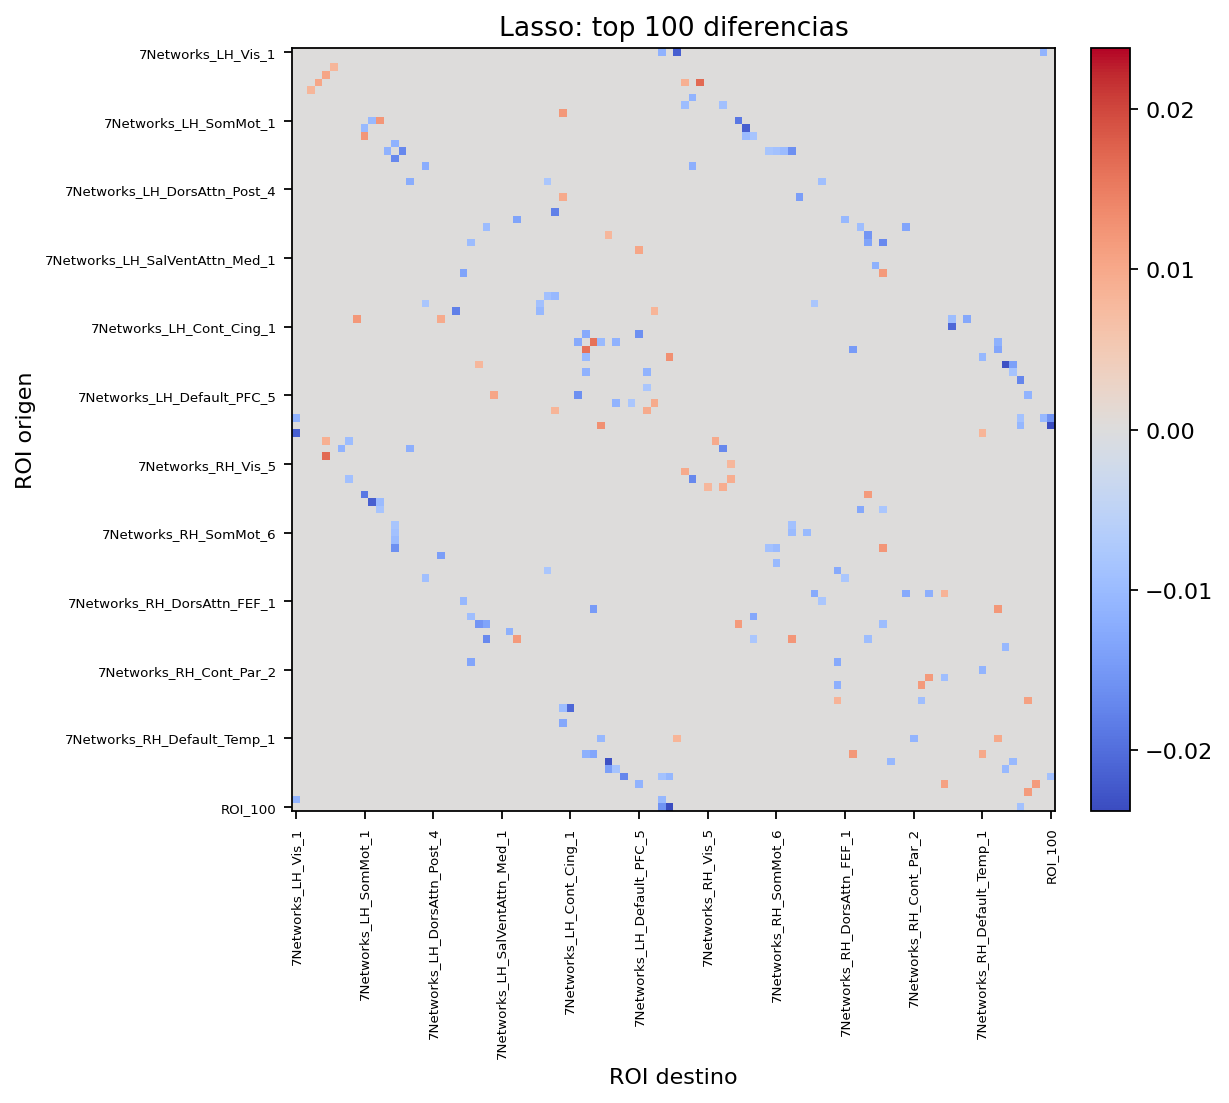

lingam_top_100_different_connections_heatmap.png


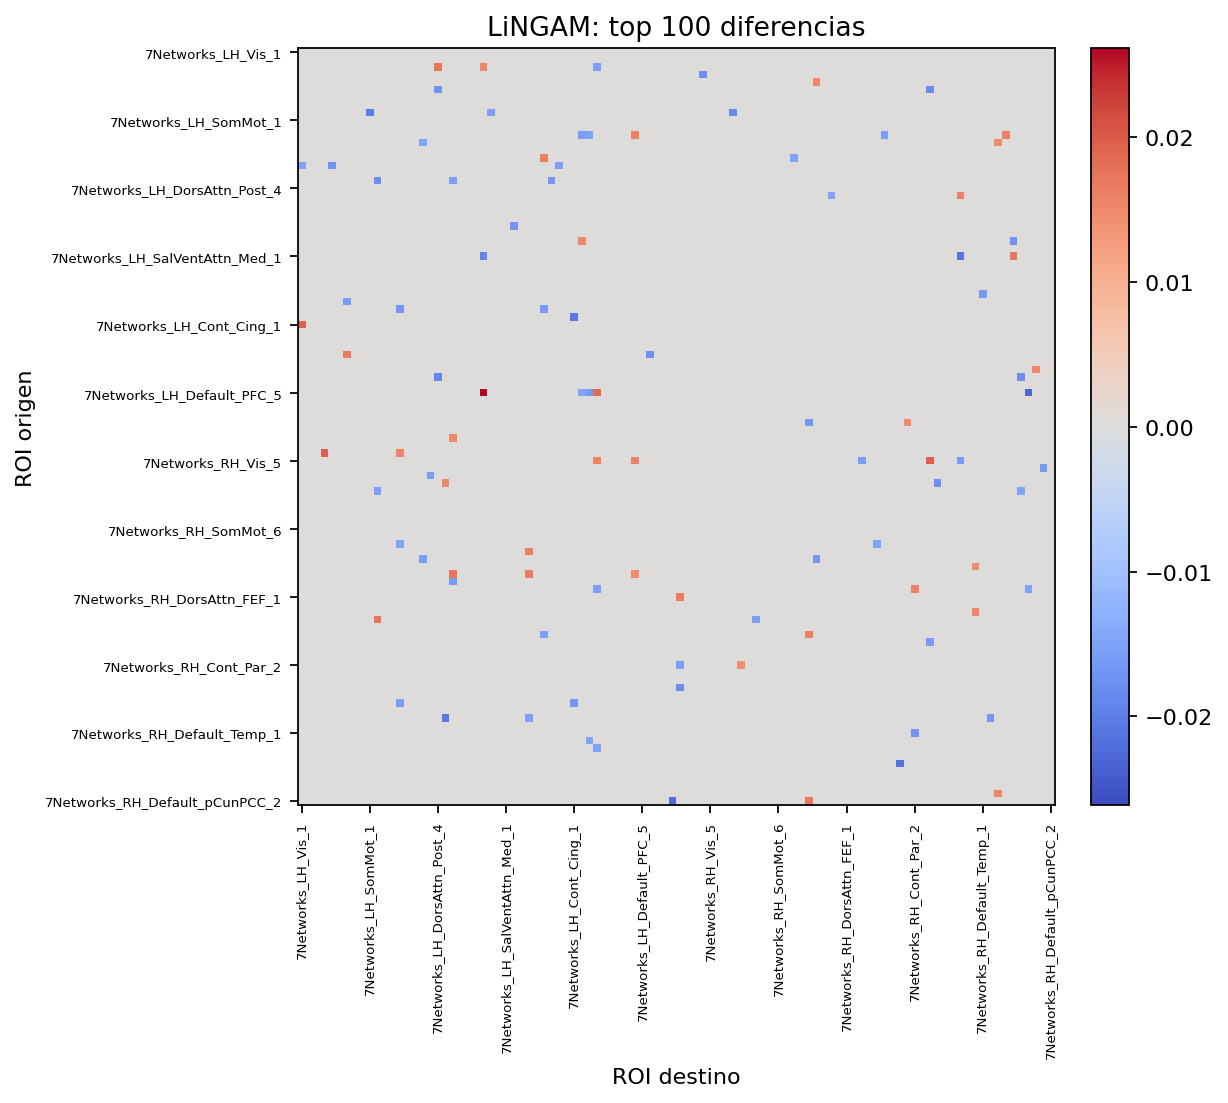

Lasso: cortes top 20, top 50 y top 100
lasso_top_20_different_connections_heatmap.png


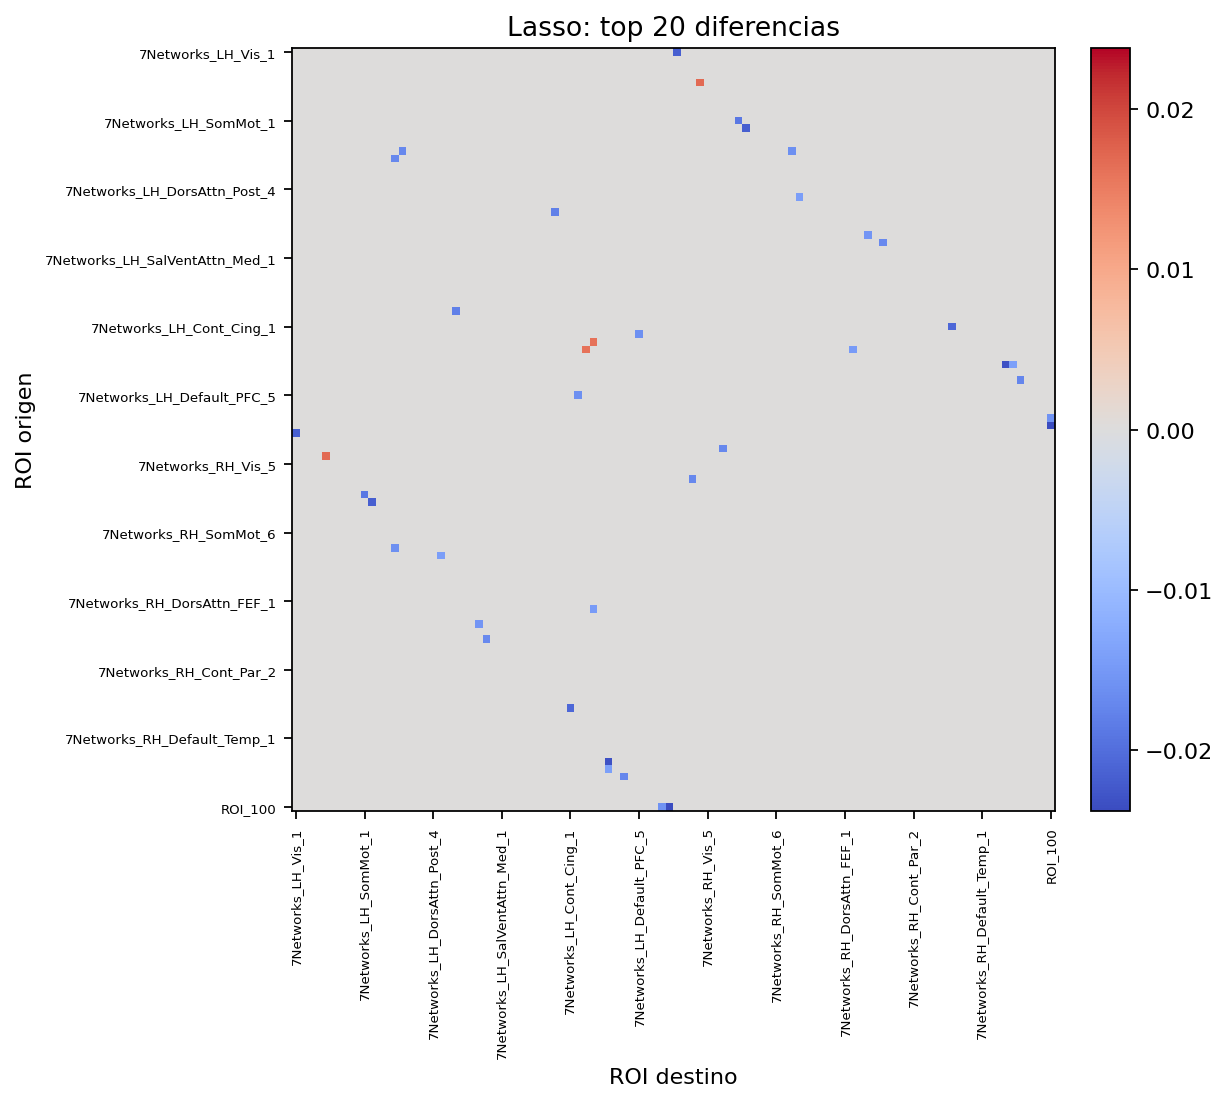

lasso_top_50_different_connections_heatmap.png


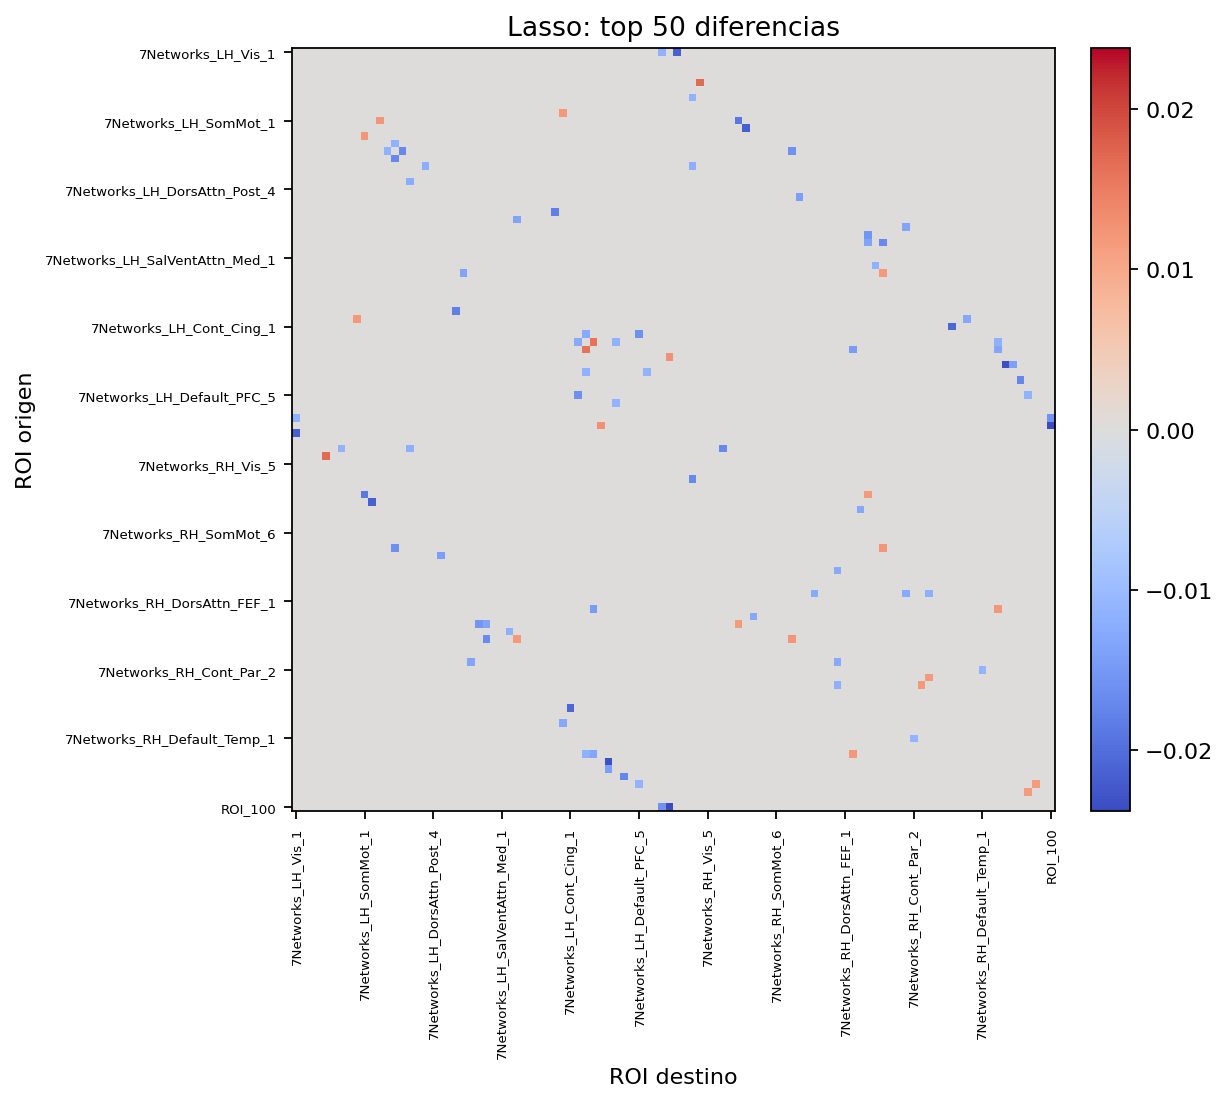

lasso_top_100_different_connections_heatmap.png


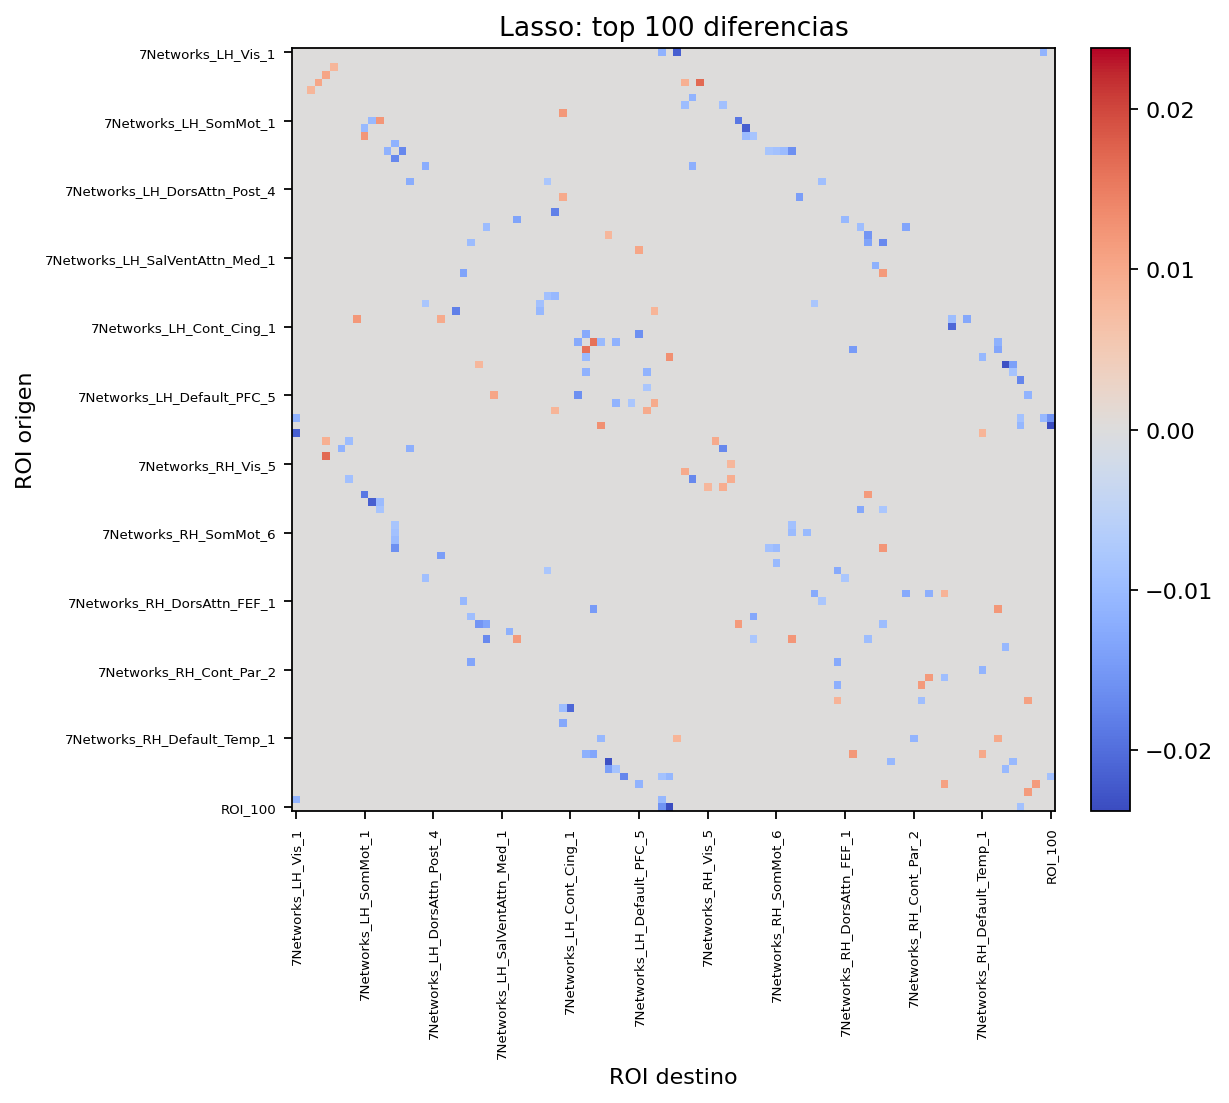

In [7]:
# CELDA 7 - Heatmaps con solo conexiones top visibles

for method in METHODS_ORDER:
    fig_path = OUT_V9 / "figures" / f"{method}_top_{TOP_N_CONNECTIONS_PER_METHOD}_different_connections_heatmap.png"
    print(fig_path.name)
    display(Image(filename=str(fig_path)))

print("Lasso: cortes top 20, top 50 y top 100")
for top_n in [20, 50, 100]:
    fig_path = OUT_V9 / "figures" / f"lasso_top_{top_n}_different_connections_heatmap.png"
    print(fig_path.name)
    display(Image(filename=str(fig_path)))


## 6. Metricas complementarias

Estas metricas apoyan la interpretacion, pero no reemplazan la inspeccion de matrices. Todas excluyen diagonal.


In [8]:
# CELDA 7 - Magnitud, sparsity y conexiones no nulas

support_summary = pd.read_csv(OUT_V9 / "tables" / "support_metrics_summary.csv")
display(
    support_summary[
        [
            "method",
            "group",
            "threshold",
            "n_subjects",
            "mean_abs_magnitude_group_matrix",
            "sparsity_group_matrix",
            "n_nonzero",
            "n_zero_like",
            "n_total_connections",
        ]
    ]
)


,method,group,threshold,n_subjects,mean_abs_magnitude_group_matrix,sparsity_group_matrix,n_nonzero,n_zero_like,n_total_connections
0,correlacion,Control,0.00001,394,0.321429,0.000000,4950,0,4950
1,correlacion,TEA,0.00001,329,0.320061,0.000000,4950,0,4950
2,correlacion,Control,0.00010,394,0.321429,0.000000,4950,0,4950
3,correlacion,TEA,0.00010,329,0.320061,0.000000,4950,0,4950
4,correlacion,Control,0.00100,394,0.321429,0.000000,4950,0,4950
5,correlacion,TEA,0.00100,329,0.320061,0.000202,4949,1,4950
6,lasso,Control,0.00001,394,0.007589,0.025455,4824,126,4950
7,lasso,TEA,0.00001,329,0.007441,0.025859,4822,128,4950
8,lasso,Control,0.00010,394,0.007589,0.098788,4461,489,4950
9,lasso,TEA,0.00010,329,0.007441,0.092121,4494,456,4950


## 7. Nota metodologica Lasso

Lasso se visualiza como correlacion parcial derivada de la matriz de precision. La matriz de precision cruda no fue guardada por el pipeline base. El estado del alpha queda documentado en CSV.


In [9]:
# CELDA 8 - Tipo de matriz y alpha de Lasso

glasso_meta = pd.read_csv(OUT_V9 / "tables" / "lasso_method_metadata.csv")
display(glasso_meta.head(20))


,method,implementation_name,public_label,stored_matrix,is_raw_precision_matrix,is_sparse_expected,alpha_status,note
0,lasso,graphical_lasso,Lasso,normalized_partial_correlation_from_precision,False,True,fixed_alpha=0.5,La matriz cacheada se interpreta como forma no...


## 8. Interpretacion para informe

Este archivo resume como leer las matrices, la sparsity, LiNGAM dirigido y la tabla de conexiones para literatura TEA.


In [10]:
# CELDA 9 - Mostrar interpretacion generada

interpretation_path = OUT_V9 / "interpretacion_resultados.md"
if not interpretation_path.exists():
    interpretation_path = generate_interpretation_report(
        source_dir=SOURCE_RESULTS,
        output_dir=OUT_V9,
    )

display(Markdown(interpretation_path.read_text(encoding="utf-8")))


# Interpretacion de resultados

## Contexto

- Corrida base: `C:\Users\crist\OneDrive\Escritorio\Tesis Segunda Entrega\resultados\pipeline_schaefer_100_all_valid_100rois_tp146`
- Salida v9: `C:\Users\crist\OneDrive\Escritorio\Tesis Segunda Entrega\resultados\pipeline_versiones9`
- Cohorte: Control=394, TEA=329.
- Metodos analizados: correlacion, lingam, lasso.

Esta interpretacion resume diferencias descriptivas entre grupos. No debe leerse como prueba causal clinica ni como biomarcador validado independiente.

## Lectura por metodo

### correlacion

- Conexion con mayor diferencia absoluta: `7Networks_LH_Default_PFC_7` -> `7Networks_RH_Cont_Par_1`.
- Valor Control=0.1116, TEA=0.1972, TEA-Control=0.0857.
- En el top 100, conexiones mayores en TEA=40 y menores en TEA=60.
- Tipo de matriz: undirected.

### lingam

- Conexion con mayor diferencia absoluta: `7Networks_LH_Default_PFC_5` -> `7Networks_LH_SalVentAttn_FrOperIns_1`.
- Valor Control=-0.0176, TEA=0.0085, TEA-Control=0.0261.
- En el top 100, conexiones mayores en TEA=36 y menores en TEA=64.
- Tipo de matriz: directed.

### lasso

- Conexion con mayor diferencia absoluta: `7Networks_LH_Default_pCunPCC_2` -> `ROI_100`.
- Valor Control=0.2733, TEA=0.2495, TEA-Control=-0.0238.
- En el top 100, conexiones mayores en TEA=26 y menores en TEA=74.
- Tipo de matriz: undirected.

## Magnitud y soporte

Resumen usando umbral 0.001 para contar conexiones no nulas en matrices promedio.

| Metodo | Grupo | Magnitud media abs. | Sparsity | Conexiones no nulas | Total |
|---|---:|---:|---:|---:|---:|
| correlacion | Control | 0.3214 | 0.0000 | 4950 | 4950 |
| correlacion | TEA | 0.3201 | 0.0002 | 4949 | 4950 |
| lasso | Control | 0.0076 | 0.4891 | 2529 | 4950 |
| lasso | TEA | 0.0074 | 0.4919 | 2515 | 4950 |
| lingam | Control | 0.0053 | 0.1709 | 8208 | 9900 |
| lingam | TEA | 0.0052 | 0.1717 | 8200 | 9900 |

## Nota metodologica sobre Lasso

- Implementacion interna: `graphical_lasso`.
- Matriz guardada: `normalized_partial_correlation_from_precision`.
- Alpha: `fixed_alpha=0.5`.
- Nota: La matriz cacheada se interpreta como forma normalizada tipo correlacion parcial derivada de la precision estimada; Alpha fijo validado y usado en la cohorte: 0.5.

## Frase sugerida para la tesis

Las matrices promedio muestran patrones de conectividad diferenciables entre Control y TEA, pero la interpretacion debe mantenerse como evidencia empirica descriptiva dentro de esta cohorte. Pearson resume conectividad funcional clasica, Lasso aproxima asociaciones directas sparse mediante precision regularizada, y LiNGAM se reporta como analisis direccional exploratorio.


## Archivos principales generados

- `resultados/pipeline_versiones9/matrices/`: matrices promedio y diferencias en `.npy` y `.csv`.
- `resultados/pipeline_versiones9/figures/`: heatmaps principales y heatmaps de conexiones top.
- `resultados/pipeline_versiones9/tables/top_different_connections.csv`: tabla central ordenada por `abs_difference`.
- `resultados/pipeline_versiones9/tables/lasso_top_20_different_connections.csv`
- `resultados/pipeline_versiones9/tables/lasso_top_50_different_connections.csv`
- `resultados/pipeline_versiones9/tables/lasso_top_100_different_connections.csv`
- `resultados/pipeline_versiones9/tables/support_metrics_summary.csv`: metricas complementarias.
- `resultados/pipeline_versiones9/tables/lasso_method_metadata.csv`: nota sobre matriz usada y alpha.
